In [1]:
import rasterio
import xarray as xr

import sys
from pathlib import Path
# Add the src directory to sys.path
sys.path.append(str(Path().resolve().parents[0] / "src"))

from datasource.chelsa import s3

In [2]:
chelsa_url = s3.format_url_month_ts("pr", 1, 2000)
chelsa_url

'https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/monthly/pr/2000/CHELSA_pr_01_2000_V.2.1.tif'

In [9]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# 1. Setup: Define Input and Target CRS
dst_crs = 'EPSG:3035'  # ETRS89-extended / LAEA Europe (Standard for EU mapping)

# 2. Define European Bounds (in WGS84 degrees, approx)
# We start with degrees because that's likely what you know
min_x, min_y, max_x, max_y = -10.0, 34.0, 45.0, 71.0 

# 3. Define the Resolutions you want (in Meters)
resolutions = [250,500, 1000, 2000, 5000, 10000] 

with rasterio.open(chelsa_url) as src:   
    for res in resolutions:
        print(f"Processing {res}m resolution...")
        
        # 2. Calculate the new dimensions automatically
        # We calculate a new transform based on the desired resolution
        dst_transform, dst_width, dst_height = calculate_default_transform(
            src.crs, src.crs, 
            src.width, src.height, 
            *src.bounds, 
            resolution=(res, res) # Force the target resolution (x, y)
        )

        # 3. Prepare the metadata for the new file
        out_profile = src.profile.copy()
        out_profile.update({
            'driver': 'GTiff',
            'crs': src.crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height,
            'compress': 'LZW',
            'tiled': True,
            'blockxsize': 256, # FIX: Explicit block size to prevent BlockError
            'blockysize': 256
        })

        output_filename = f"chelsa_europe_{res}m.tif"

        # 4. Create the destination file and fill it using reproject
        with rasterio.open(output_filename, 'w', **out_profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst.crs,
                resampling=Resampling.bilinear # or .nearest, .average
            )
            
        print(f" -> Saved: {output_filename} (Size: {dst_width}x{dst_height})")

print("Done.")

Processing 250m resolution...
 -> Saved: chelsa_europe_250m.tif (Size: 2x1)
Processing 500m resolution...
 -> Saved: chelsa_europe_500m.tif (Size: 1x1)
Processing 1000m resolution...
 -> Saved: chelsa_europe_1000m.tif (Size: 1x1)
Processing 2000m resolution...
 -> Saved: chelsa_europe_2000m.tif (Size: 1x1)
Processing 5000m resolution...
 -> Saved: chelsa_europe_5000m.tif (Size: 1x1)
Processing 10000m resolution...


CPLE_AppDefinedError: chelsa_europe_10000m.tif: MissingRequired:TIFF directory is missing required "StripOffsets" field

In [16]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import os

dst_crs = 'EPSG:3035'
wgs84_bounds = (-10.0, 34.0, 45.0, 71.0)
resolutions = [250, 500, 1000, 2000, 5000, 10000]

with rasterio.open(chelsa_url) as src:
    # ... (Transform bounds logic remains the same) ...
    dst_w, dst_s, dst_e, dst_n = transform_bounds('EPSG:4326', dst_crs, *wgs84_bounds)

    for res in resolutions:
        print(f"\nProcessing {res}m resolution...")

        dst_width = int((dst_e - dst_w) / res)
        dst_height = int((dst_n - dst_s) / res)
        dst_transform = from_origin(dst_w, dst_n, res, res)

        out_profile = src.profile.copy()
        out_profile.update({
            'driver': 'GTiff',
            'crs': dst_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height,
            'count': 1,
            'compress': 'LZW',
            'tiled': True,
            'blockxsize': 256, 
            'blockysize': 256
        })

        output_filename = f"chelsa_europe_{res}m.tif"

        # --- THE FIX IS HERE ---
        # Explicitly remove the file if it exists to prevent "Zombie" errors
        if os.path.exists(output_filename):
            try:
                os.remove(output_filename)
                print(f" -> Deleted existing corrupt file: {output_filename}")
            except PermissionError:
                print(f" -> ERROR: Could not delete {output_filename}. Close any other programs using it!")

        # Write and Reproject
        with rasterio.open(output_filename, 'w', **out_profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                src_nodata=src.nodata,
                dst_nodata=src.nodata # Keep existing nodata
            )
            print(f" -> Saved: {output_filename}")

print("\nProcessing Complete.")


Processing 250m resolution...
 -> Deleted existing corrupt file: chelsa_europe_250m.tif
 -> Saved: chelsa_europe_250m.tif

Processing 500m resolution...
 -> Deleted existing corrupt file: chelsa_europe_500m.tif
 -> Saved: chelsa_europe_500m.tif

Processing 1000m resolution...
 -> Deleted existing corrupt file: chelsa_europe_1000m.tif
 -> Saved: chelsa_europe_1000m.tif

Processing 2000m resolution...
 -> Deleted existing corrupt file: chelsa_europe_2000m.tif
 -> Saved: chelsa_europe_2000m.tif

Processing 5000m resolution...
 -> Deleted existing corrupt file: chelsa_europe_5000m.tif
 -> Saved: chelsa_europe_5000m.tif

Processing 10000m resolution...
 -> Deleted existing corrupt file: chelsa_europe_10000m.tif
 -> Saved: chelsa_europe_10000m.tif

Processing Complete.


In [18]:
import rasterio
import numpy as np

# Check the 250m file
with rasterio.open("chelsa_europe_10000m.tif") as src:
    data = src.read(1, masked=True) # masked=True ignores NoData
    
    print(f"File Size: {src.width}x{src.height}")
    print(f"Minimum Value: {np.min(data)}")
    print(f"Maximum Value: {np.max(data)}")
    print(f"Mean Value:    {np.mean(data):.2f}")

File Size: 499x442
Minimum Value: 0
Maximum Value: 924
Mean Value:    64.51


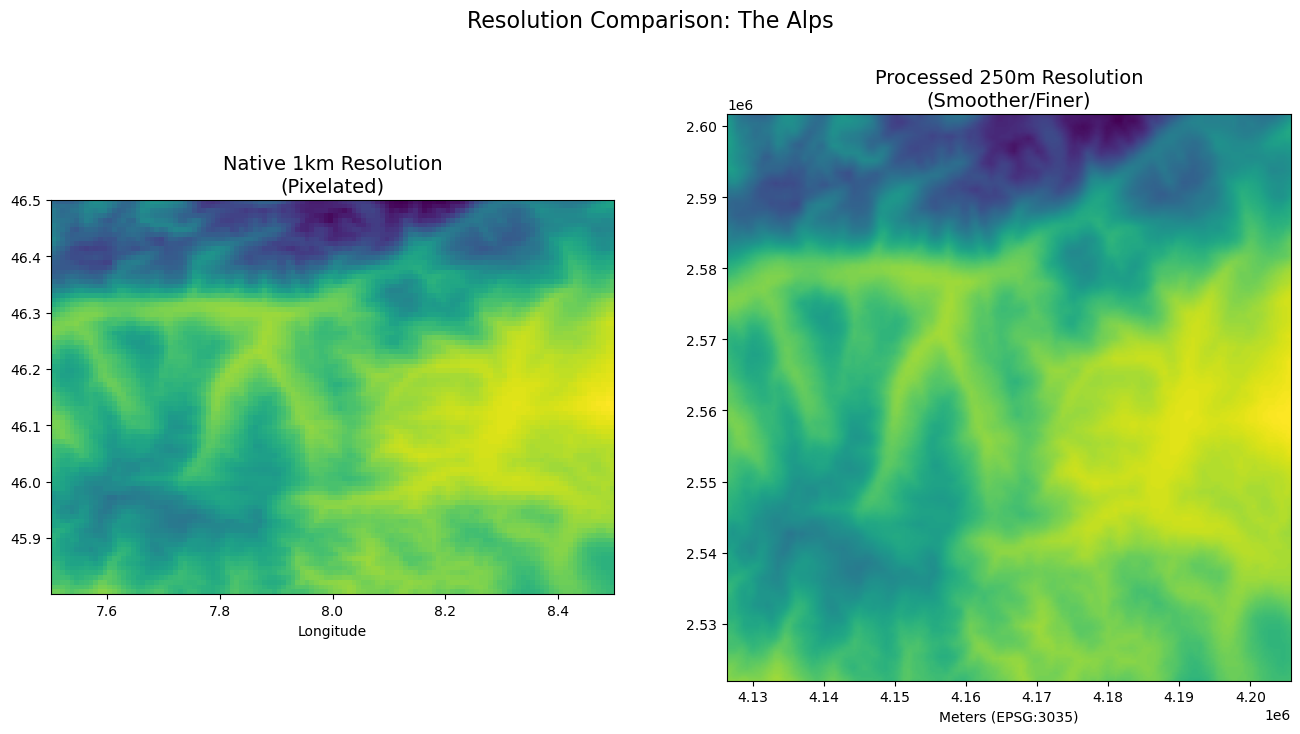

In [26]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import matplotlib.pyplot as plt

# 1. Configuration
native_file = "chelsa_europe_precip_native.tif" # The 1km file we just made
processed_file = "chelsa_europe_250m.tif"       # Your 250m reprojected file

# Define a small zoom window over the Alps (Switzerland/Italy border)
# This area has high detail (mountains) that will show off the resolution.
# WGS84 Coords (Lon, Lat)
zoom_bounds = (7.5, 45.8, 8.5, 46.5) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- PLOT 1: NATIVE 1KM ---
with rasterio.open(native_file) as src:
    # Convert zoom bounds to the native file's projection (WGS84)
    window = from_bounds(*zoom_bounds, src.transform)
    data_1km = src.read(1, window=window)
    
    show(data_1km, transform=src.window_transform(window), ax=ax1, cmap='viridis_r')
    ax1.set_title(f"Native 1km Resolution\n(Pixelated)", fontsize=14)
    ax1.set_xlabel("Longitude")

# --- PLOT 2: PROCESSED 250M ---
with rasterio.open(processed_file) as src:
    # We must transform the WGS84 zoom box into the File's CRS (EPSG:3035)
    from rasterio.warp import transform_bounds
    left, bottom, right, top = transform_bounds(
        "EPSG:4326", src.crs, *zoom_bounds
    )
    
    # Read the window in the 250m file
    window = from_bounds(left, bottom, right, top, src.transform)
    data_250m = src.read(1, window=window)
    
    show(data_250m, transform=src.window_transform(window), ax=ax2, cmap='viridis_r')
    ax2.set_title(f"Processed 250m Resolution\n(Smoother/Finer)", fontsize=14)
    ax2.set_xlabel("Meters (EPSG:3035)")

plt.suptitle("Resolution Comparison: The Alps", fontsize=16)
plt.show()

In [27]:
import rasterio
import os

# 1. Define the files you want to check
# Make sure these match the filenames you used in previous steps
files_to_check = [
    "chelsa_europe_precip_native.tif", # The 1km native cut
    "chelsa_europe_250m.tif",
    "chelsa_europe_500m.tif",
    "chelsa_europe_1000m.tif",
    "chelsa_europe_2000m.tif",
    "chelsa_europe_5000m.tif",
    "chelsa_europe_10000m.tif"
]

print(f"{'FILENAME':<30} | {'GRID SIZE (Px)':<20} | {'TOTAL PIXELS':<15} | {'FILE SIZE'}")
print("-" * 85)

for filename in files_to_check:
    if os.path.exists(filename):
        # Get file size in MB
        size_bytes = os.path.getsize(filename)
        size_mb = size_bytes / (1024 * 1024)
        
        # Get raster dimensions using Rasterio
        try:
            with rasterio.open(filename) as src:
                width = src.width
                height = src.height
                total_pixels = width * height
                
                # Format the pixel count (e.g., 350M) for readability
                if total_pixels > 1_000_000:
                    pixel_str = f"{total_pixels/1_000_000:.1f} M"
                else:
                    pixel_str = f"{total_pixels/1_000:.1f} K"
                
                print(f"{filename:<30} | {width} x {height:<9} | {pixel_str:<15} | {size_mb:.2f} MB")
        except Exception as e:
            print(f"{filename:<30} | {'Error reading header':<20} | {'-':<15} | {size_mb:.2f} MB")
    else:
        print(f"{filename:<30} | {'[FILE NOT FOUND]':<20} | {'-':<15} | -")

print("-" * 85)

FILENAME                       | GRID SIZE (Px)       | TOTAL PIXELS    | FILE SIZE
-------------------------------------------------------------------------------------
chelsa_europe_precip_native.tif | 6600 x 4440      | 29.3 M          | 11.25 MB
chelsa_europe_250m.tif         | 19982 x 17688     | 353.4 M         | 70.51 MB
chelsa_europe_500m.tif         | 9991 x 8844      | 88.4 M          | 25.67 MB
chelsa_europe_1000m.tif        | 4995 x 4422      | 22.1 M          | 9.00 MB
chelsa_europe_2000m.tif        | 2497 x 2211      | 5.5 M           | 3.03 MB
chelsa_europe_5000m.tif        | 999 x 884       | 883.1 K         | 0.66 MB
chelsa_europe_10000m.tif       | 499 x 442       | 220.6 K         | 0.20 MB
-------------------------------------------------------------------------------------


In [34]:
chelsa_bio_url = "https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/bioclim/bio01/1981-2010/CHELSA_bio01_1981-2010_V.2.1.tif"
chelsa_bio_url

'https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/bioclim/bio01/1981-2010/CHELSA_bio01_1981-2010_V.2.1.tif'

In [35]:
dst_crs = 'EPSG:3035'
wgs84_bounds = (-10.0, 34.0, 45.0, 71.0)
resolutions = [250, 500, 1000, 2000, 5000, 10000]

with rasterio.open(chelsa_bio_url) as src:
    # ... (Transform bounds logic remains the same) ...
    dst_w, dst_s, dst_e, dst_n = transform_bounds('EPSG:4326', dst_crs, *wgs84_bounds)

    for res in resolutions:
        print(f"\nProcessing {res}m resolution...")

        dst_width = int((dst_e - dst_w) / res)
        dst_height = int((dst_n - dst_s) / res)
        dst_transform = from_origin(dst_w, dst_n, res, res)

        out_profile = src.profile.copy()
        out_profile.update({
            'driver': 'GTiff',
            'crs': dst_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height,
            'count': 1,
            'compress': 'LZW',
            'tiled': True,
            'blockxsize': 256, 
            'blockysize': 256
        })

        output_filename = f"chelsa_europe_bio1_{res}m.tif"

        # --- THE FIX IS HERE ---
        # Explicitly remove the file if it exists to prevent "Zombie" errors
        if os.path.exists(output_filename):
            try:
                os.remove(output_filename)
                print(f" -> Deleted existing corrupt file: {output_filename}")
            except PermissionError:
                print(f" -> ERROR: Could not delete {output_filename}. Close any other programs using it!")

        # Write and Reproject
        with rasterio.open(output_filename, 'w', **out_profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                src_nodata=src.nodata,
                dst_nodata=src.nodata # Keep existing nodata
            )
            print(f" -> Saved: {output_filename}")

print("\nProcessing Complete.")


Processing 250m resolution...
 -> Saved: chelsa_europe_bio1_250m.tif

Processing 500m resolution...
 -> Saved: chelsa_europe_bio1_500m.tif

Processing 1000m resolution...
 -> Saved: chelsa_europe_bio1_1000m.tif

Processing 2000m resolution...
 -> Saved: chelsa_europe_bio1_2000m.tif

Processing 5000m resolution...
 -> Saved: chelsa_europe_bio1_5000m.tif

Processing 10000m resolution...
 -> Saved: chelsa_europe_bio1_10000m.tif

Processing Complete.
